<a href="https://colab.research.google.com/github/briskicedteaa/Machine-Learning-for-Molecular-Data/blob/main/Feature_Importance_(Random_Forest).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [66]:
df = pd.read_csv('/content/Ligands2.csv', sep =';' )
df = df.drop(columns=df.columns.difference(['Ligand Efficiency LE', 'Ligand Efficiency LLE', 'Ligand Efficiency BEI', 'Ligand Efficiency SEI', 'Molecular Weight', 'Standard Value', 'AlogP']))
df = df.dropna()
df

,Molecular Weight,AlogP,Standard Value,Ligand Efficiency BEI,Ligand Efficiency LE,Ligand Efficiency LLE,Ligand Efficiency SEI
0,472.67,4.21,60.00,15.28,0.29,3.01,12.61
8,323.39,3.29,657.00,19.12,0.35,2.89,15.95
9,413.52,5.25,22300.00,11.25,0.20,-0.60,12.00
10,379.50,4.36,7.00,21.49,0.40,3.79,21.03
13,427.55,3.69,280.00,15.33,0.28,2.86,6.84
...,...,...,...,...,...,...,...
20124,351.35,3.88,1670.00,16.44,0.33,1.90,12.09
20125,433.49,7.26,7.10,18.80,0.36,0.89,22.05
20126,471.59,8.33,70.00,15.17,0.30,-1.18,19.36
20128,539.81,7.45,7.63,15.04,0.30,0.67,20.94


In [67]:
model = RandomForestRegressor(
    random_state=42
)

In [68]:
x = df[
    [
        'Molecular Weight',
        'AlogP',
        'Ligand Efficiency BEI',
        'Ligand Efficiency LE',
        'Ligand Efficiency LLE',
        'Ligand Efficiency SEI'
    ]
]
y = df['Standard Value']

print(f"Shape of x before split: {x.shape}")
print(f"Shape of y before split: {y.shape}")

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=4
)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shape of x before split: (7999, 6)
Shape of y before split: (7999,)
x_train shape: (6399, 6)
x_test shape: (1600, 6)
y_train shape: (6399,)
y_test shape: (1600,)


In [ ]:
model = RandomForestRegressor(
    random_state=42
)

model.fit(x_train, y_train)

feature_labels = [
    'Molecular Weight',
    'AlogP',
    'Ligand Efficiency BEI',
    'Ligand Efficiency LE',
    'Ligand Efficiency LLE',
    'Ligand Efficiency SEI'
]

feature_importance_df = pd.DataFrame({
    'Feature': feature_labels,
    'Importance': model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                 Feature  Importance
0       Molecular Weight    0.238580
1                  AlogP    0.221919
2  Ligand Efficiency BEI    0.214433
4  Ligand Efficiency LLE    0.190852
5  Ligand Efficiency SEI    0.090242
3   Ligand Efficiency LE    0.043973


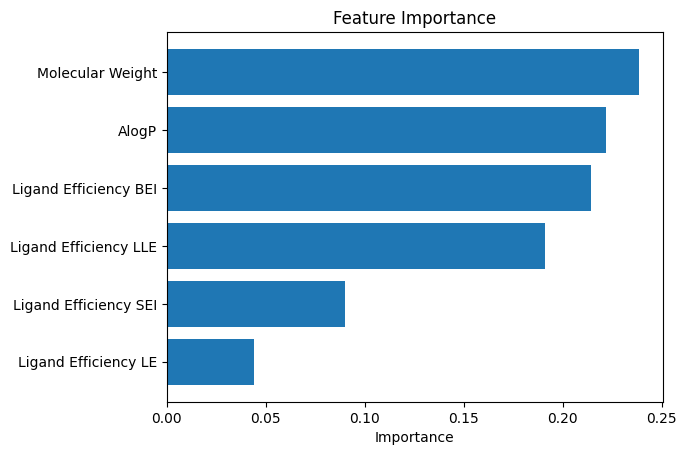

In [69]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], align='center')
ax.yaxis.set_inverted(True)
ax.set_xlabel('Importance')
ax.set_title('Feature Importance')

plt.show()